# Sensibilidad y robustez del target

**TFM:** estimación de riesgo de mercado — análisis **complementario**.

El target principal del trabajo sigue siendo **`target_risk_20d`** (drawdown ≤ −5% **o** vol futura ≥ 20% anualizada, horizonte 20 días).

Este notebook evalúa si las conclusiones generales dependen excesivamente de esa definición concreta, **sin sustituir** la comparativa principal de los Notebooks 04–06.


## 0. Librerías, rutas y constantes

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception:
    xgb = None
    XGBOOST_AVAILABLE = False

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELING_DIR = DATA_PROCESSED / "modeling"
REPORTS_TABLES = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES = PROJECT_ROOT / "reports" / "figures"
REPORTS_TABLES.mkdir(parents=True, exist_ok=True)
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

TRADING_DAYS = 252
TRAIN_END = pd.Timestamp("2015-12-31")
VAL_START = pd.Timestamp("2016-02-02")
VAL_END = pd.Timestamp("2019-12-31")
TEST_START = pd.Timestamp("2020-01-31")

DRAWDOWN_THRESHOLDS = [0.04, 0.05, 0.07]
VOL_THRESHOLDS = [0.18, 0.20, 0.25]
BASE_DD = 0.05
BASE_VOL = 0.20
HORIZONS = [10, 20, 30]

THRESHOLD_GRID = np.round(np.arange(0.05, 0.951, 0.01), 2)
RANDOM_STATE = 42

XGB_PARAMS = dict(
    n_estimators=400, max_depth=3, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
)

print("XGBoost disponible:", XGBOOST_AVAILABLE)


XGBoost disponible: True


## PARTE 1 — Carga de datos

In [2]:
df_initial = pd.read_csv(DATA_PROCESSED / "initial_market_dataset.csv", parse_dates=["date"])
df_target_full = pd.read_csv(DATA_PROCESSED / "dataset_with_target.csv", parse_dates=["date"])

FEATURE_COLS = (
    MODELING_DIR / "feature_columns.txt"
).read_text(encoding="utf-8").strip().split("\n")

model_comparison = pd.read_csv(REPORTS_TABLES / "model_comparison_summary.csv")
vix_auc_main = pd.read_csv(REPORTS_TABLES / "vix_score_auc_comparison.csv")

print("Filas initial:", len(df_initial), "| con target:", len(df_target_full))
print("Features:", len(FEATURE_COLS))
display(model_comparison)
display(vix_auc_main)


Filas initial: 9159 | con target: 9139
Features: 28


,modelo,split,f1,precision,recall,pr_auc,C,threshold
0,VIX rule,validation,0.3556,0.3128,0.4118,NaN,NaN,NaN
1,VIX rule,test,0.5420,0.4017,0.8330,NaN,NaN,NaN
2,LogReg best all_features,validation,0.4468,0.4315,0.4632,0.3582,0.10,0.91
3,LogReg best all_features,test,0.4384,0.2828,0.9755,0.3050,0.10,0.91
4,LogReg best reduced_no_level,validation,0.3746,0.3081,0.4779,0.2489,0.01,0.44
5,LogReg best reduced_no_level,test,0.5525,0.4106,0.8441,0.6309,0.01,0.44
6,RandomForest (best),validation,0.4094,0.3398,0.5147,0.2982,NaN,NaN
7,RandomForest (best),test,0.5198,0.3806,0.8196,0.6290,NaN,NaN
8,XGBoost (best),validation,0.5368,0.5368,0.5368,0.4363,NaN,NaN
9,XGBoost (best),test,0.4923,0.4839,0.5011,0.5400,NaN,NaN


,modelo,split,roc_auc,pr_auc
0,VIX (score continuo),validation,0.688789,0.290165
1,VIX (score continuo),test,0.759457,0.603240
2,Random Forest,validation,0.619905,0.298165
3,XGBoost,validation,0.747266,0.436271
4,Random Forest,test,0.754999,0.628970
5,XGBoost,test,0.670794,0.539969


### Nota metodológica

- Features: solo las de `feature_columns.txt` (sin variables futuras ni targets auxiliares).
- Particiones por **fechas fijas** del proyecto (train / validation / test).
- La metodología principal (Notebook 03) incluye **gap de purga** de 20 días; en este análisis complementario usamos fronteras temporales comparables **sin reimplementar el gap**, salvo donde se indique.


## PARTE 2 — Robustez a umbrales (horizonte fijo 20 días)

,drawdown_threshold_pct,vol_threshold_pct,positive_rate_full,positive_rate_train,positive_rate_validation,positive_rate_test,is_baseline_target
0,4.0,18.0,0.3255,0.3323,0.1897,0.3763,False
1,4.0,20.0,0.2911,0.3001,0.1633,0.3276,False
2,4.0,25.0,0.2471,0.2523,0.1420,0.2910,False
3,5.0,18.0,0.2923,0.2955,0.1724,0.3468,False
4,5.0,20.0,0.2490,0.2547,0.1379,0.2878,True
5,5.0,25.0,0.1919,0.1950,0.1014,0.2372,False
6,7.0,18.0,0.2660,0.2679,0.1542,0.3199,False
7,7.0,20.0,0.2114,0.2144,0.1146,0.2519,False
8,7.0,25.0,0.1351,0.1382,0.0487,0.1782,False


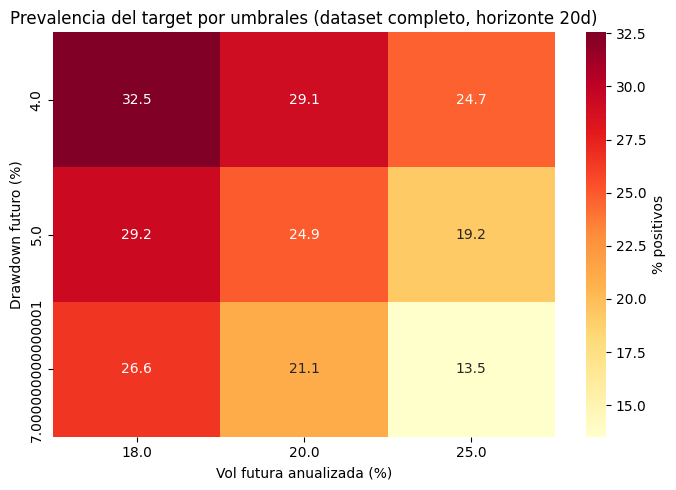

In [3]:
def compute_future_drawdown_and_vol(close, horizon, trading_days=TRADING_DAYS):
    n = len(close)
    future_dd = np.full(n, np.nan)
    future_vol = np.full(n, np.nan)
    for i in range(n - horizon):
        future_prices = close[i + 1 : i + horizon + 1]
        future_dd[i] = future_prices.min() / close[i] - 1
        prices = close[i : i + horizon + 1]
        daily_returns = np.diff(prices) / prices[:-1]
        future_vol[i] = daily_returns.std(ddof=1) * np.sqrt(trading_days)
    return future_dd, future_vol


def make_combined_target(future_dd, future_vol, dd_thr, vol_thr):
    return ((future_dd <= -dd_thr) | (future_vol >= vol_thr)).astype(int)


def assign_splits(dates):
    train = dates <= TRAIN_END
    val = (dates >= VAL_START) & (dates <= VAL_END)
    test = dates >= TEST_START
    return train, val, test


def positive_rates(y, dates):
    train, val, test = assign_splits(dates)
    out = {"full": y.mean()}
    for name, mask in [("train", train), ("validation", val), ("test", test)]:
        out[name] = y[mask].mean() if mask.sum() else np.nan
    return out


# Dataset base 20d con columnas futuras ya calculadas
df20 = df_target_full.dropna(subset=["future_drawdown_20d", "future_vol_20d_ann"]).copy()
df20 = df20.dropna(subset=FEATURE_COLS).reset_index(drop=True)

dist_rows = []
for dd in DRAWDOWN_THRESHOLDS:
    for vol in VOL_THRESHOLDS:
        y = make_combined_target(
            df20["future_drawdown_20d"].values,
            df20["future_vol_20d_ann"].values,
            dd, vol,
        )
        rates = positive_rates(pd.Series(y), df20["date"])
        dist_rows.append({
            "drawdown_threshold_pct": dd * 100,
            "vol_threshold_pct": vol * 100,
            "positive_rate_full": rates["full"],
            "positive_rate_train": rates["train"],
            "positive_rate_validation": rates["validation"],
            "positive_rate_test": rates["test"],
            "is_baseline_target": (dd == BASE_DD and vol == BASE_VOL),
        })

target_threshold_sensitivity = pd.DataFrame(dist_rows)
target_threshold_sensitivity.to_csv(
    REPORTS_TABLES / "target_threshold_sensitivity_distribution.csv", index=False
)
display(target_threshold_sensitivity.round(4))

# Heatmap — tasa global de positivos
heat = target_threshold_sensitivity.pivot(
    index="drawdown_threshold_pct", columns="vol_threshold_pct", values="positive_rate_full"
) * 100
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(heat, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar_kws={"label": "% positivos"})
ax.set_title("Prevalencia del target por umbrales (dataset completo, horizonte 20d)")
ax.set_xlabel("Vol futura anualizada (%)")
ax.set_ylabel("Drawdown futuro (%)")
fig.tight_layout()
fig.savefig(REPORTS_FIGURES / "target_threshold_positive_rate_heatmap.png", dpi=150)
plt.show()


## PARTE 3 — VIX como score continuo en cada target alternativo

In [4]:
vix_auc_rows = []
for dd in DRAWDOWN_THRESHOLDS:
    for vol in VOL_THRESHOLDS:
        y = make_combined_target(
            df20["future_drawdown_20d"].values,
            df20["future_vol_20d_ann"].values,
            dd, vol,
        )
        train, val, test = assign_splits(df20["date"])
        for split_name, mask in [("validation", val), ("test", test)]:
            y_s = pd.Series(y)[mask].values
            vix_s = df20.loc[mask, "vix"].values
            if len(np.unique(y_s)) < 2:
                roc, pr = np.nan, np.nan
            else:
                roc = roc_auc_score(y_s, vix_s)
                pr = average_precision_score(y_s, vix_s)
            vix_auc_rows.append({
                "drawdown_threshold_pct": dd * 100,
                "vol_threshold_pct": vol * 100,
                "split": split_name,
                "roc_auc": roc,
                "pr_auc": pr,
                "is_baseline_target": (dd == BASE_DD and vol == BASE_VOL),
            })

vix_threshold_sensitivity = pd.DataFrame(vix_auc_rows)
vix_threshold_sensitivity.to_csv(
    REPORTS_TABLES / "vix_threshold_sensitivity_auc.csv", index=False
)
display(vix_threshold_sensitivity.round(4))


,drawdown_threshold_pct,vol_threshold_pct,split,roc_auc,pr_auc,is_baseline_target
0,4.0,18.0,validation,0.7345,0.4473,False
1,4.0,18.0,test,0.7619,0.6982,False
2,4.0,20.0,validation,0.6938,0.3175,False
3,4.0,20.0,test,0.7174,0.5945,False
4,4.0,25.0,validation,0.6512,0.2183,False
5,4.0,25.0,test,0.6742,0.4972,False
6,5.0,18.0,validation,0.7396,0.4445,False
7,5.0,18.0,test,0.8015,0.7143,False
8,5.0,20.0,validation,0.6888,0.2902,True
9,5.0,20.0,test,0.7595,0.6032,True


### Interpretación — VIX bajo umbrales alternativos

- El **VIX como score continuo** mantiene **ROC-AUC y PR-AUC elevados** en la mayoría de combinaciones, especialmente en **test**.
- Targets **más laxos** (p.ej. 4%/18%) aumentan la prevalencia y suelen elevar PR-AUC; targets **más estrictos** (7%/25%) la reducen.
- El target principal **5%/20%** sitúa la prevalencia en un rango intermedio (~25% global, ~14% validation, ~29% test), razonable para clasificación binaria.
- Esto refuerza que el VIX es un **baseline financiero fuerte** frente al cual los modelos ML deben aportar valor medible.


## PARTE 4 — Robustez ligera con XGBoost fijo

> **Nota:** esta prueba **no sustituye** la comparativa principal del TFM. Es sensibilidad complementaria con configuración fija (Notebook 05), sin tuning.


,drawdown_threshold_pct,vol_threshold_pct,positive_rate_train,positive_rate_validation,positive_rate_test,best_threshold_validation,val_precision,val_recall,val_f1,val_roc_auc,...,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc,test_tn,test_fp,test_fn,test_tp,is_baseline_target
0,4.0,18.0,0.3323,0.1897,0.3763,0.84,0.3906,0.4866,0.4333,0.6863,...,0.4737,0.5673,0.5163,0.6496,0.6273,603,370,254,333,False
1,4.0,20.0,0.3001,0.1633,0.3276,0.75,0.3165,0.5839,0.4105,0.7069,...,0.3969,0.7006,0.5067,0.6570,0.5368,505,544,153,358,False
2,4.0,25.0,0.2523,0.1420,0.2910,0.74,0.3214,0.4500,0.3750,0.6780,...,0.2903,0.3767,0.3279,0.5350,0.3163,688,418,283,171,False
3,5.0,18.0,0.2955,0.1724,0.3468,0.86,0.4293,0.4647,0.4463,0.6887,...,0.4612,0.5490,0.5013,0.6586,0.6308,672,347,244,297,False
4,5.0,20.0,0.2547,0.1379,0.2878,0.83,0.5368,0.5368,0.5368,0.7473,...,0.4839,0.5011,0.4923,0.6708,0.5400,871,240,224,225,True
5,5.0,25.0,0.1950,0.1014,0.2372,0.79,0.2791,0.3600,0.3144,0.6736,...,0.3037,0.1568,0.2068,0.5798,0.2820,1057,133,312,58,False
6,7.0,18.0,0.2679,0.1542,0.3199,0.95,0.3962,0.2763,0.3256,0.6436,...,0.6864,0.3026,0.4200,0.6466,0.5591,992,69,348,151,False
7,7.0,20.0,0.2144,0.1146,0.2519,0.79,0.1693,0.8584,0.2828,0.6714,...,0.2898,0.5191,0.3719,0.5820,0.3599,667,500,189,204,False
8,7.0,25.0,0.1382,0.0487,0.1782,0.76,0.0938,0.9375,0.1705,0.7209,...,0.1342,0.2302,0.1695,0.4989,0.1699,869,413,214,64,False


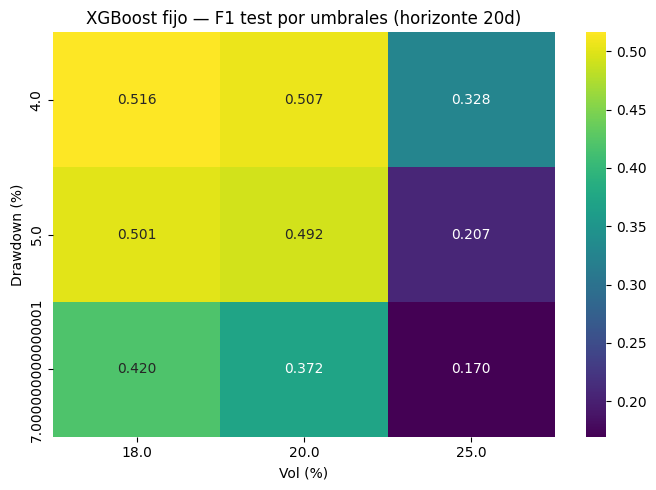

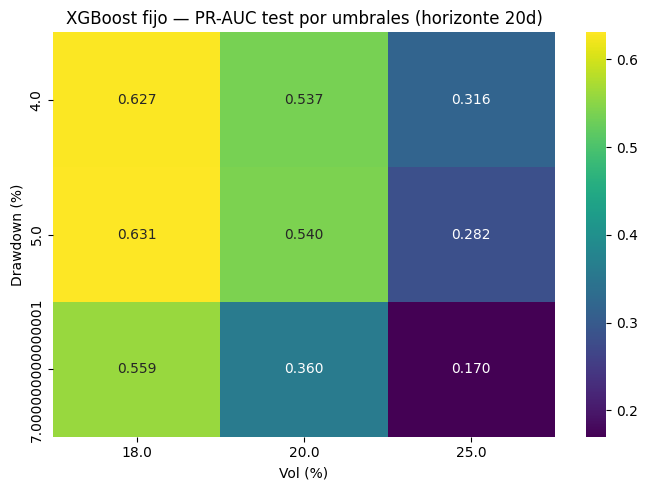

In [5]:
def find_best_threshold_f1(y_true, y_proba, grid=THRESHOLD_GRID):
    best_thr, best_score = grid[0], (-1.0, -1.0, -1.0)
    for thr in grid:
        pred = (y_proba >= thr).astype(int)
        score = (
            f1_score(y_true, pred, zero_division=0),
            precision_score(y_true, pred, zero_division=0),
            thr,
        )
        if score > best_score:
            best_score, best_thr = score, thr
    return float(best_thr)


def eval_xgb_fixed(X_train, y_train, X_val, y_val, X_test, y_test):
    spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
    model = xgb.XGBClassifier(
        **XGB_PARAMS, eval_metric="logloss", random_state=RANDOM_STATE,
        n_jobs=-1, scale_pos_weight=spw, use_label_encoder=False,
    )
    model.fit(X_train, y_train)
    proba_val = model.predict_proba(X_val)[:, 1]
    proba_test = model.predict_proba(X_test)[:, 1]
    best_thr = find_best_threshold_f1(y_val, proba_val)
    pred_val = (proba_val >= best_thr).astype(int)
    pred_test = (proba_test >= best_thr).astype(int)

    def metrics(y, pred, proba):
        tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
        return {
            "precision": precision_score(y, pred, zero_division=0),
            "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0),
            "roc_auc": roc_auc_score(y, proba) if len(np.unique(y)) > 1 else np.nan,
            "pr_auc": average_precision_score(y, proba) if len(np.unique(y)) > 1 else np.nan,
            "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        }

    return best_thr, metrics(y_val, pred_val, proba_val), metrics(y_test, pred_test, proba_test)


train_m, val_m, test_m = assign_splits(df20["date"])
X_train = df20.loc[train_m, FEATURE_COLS]
X_val = df20.loc[val_m, FEATURE_COLS]
X_test = df20.loc[test_m, FEATURE_COLS]

xgb_rows = []
if not XGBOOST_AVAILABLE:
    print("XGBoost no disponible — omitiendo Parte 4")
else:
    for dd in DRAWDOWN_THRESHOLDS:
        for vol in VOL_THRESHOLDS:
            y_all = make_combined_target(
                df20["future_drawdown_20d"].values,
                df20["future_vol_20d_ann"].values,
                dd, vol,
            )
            y_train = pd.Series(y_all)[train_m].values
            y_val = pd.Series(y_all)[val_m].values
            y_test = pd.Series(y_all)[test_m].values
            rates = positive_rates(pd.Series(y_all), df20["date"])
            thr, m_val, m_test = eval_xgb_fixed(X_train, y_train, X_val, y_val, X_test, y_test)
            xgb_rows.append({
                "drawdown_threshold_pct": dd * 100,
                "vol_threshold_pct": vol * 100,
                "positive_rate_train": rates["train"],
                "positive_rate_validation": rates["validation"],
                "positive_rate_test": rates["test"],
                "best_threshold_validation": thr,
                "val_precision": m_val["precision"], "val_recall": m_val["recall"],
                "val_f1": m_val["f1"], "val_roc_auc": m_val["roc_auc"], "val_pr_auc": m_val["pr_auc"],
                "test_precision": m_test["precision"], "test_recall": m_test["recall"],
                "test_f1": m_test["f1"], "test_roc_auc": m_test["roc_auc"], "test_pr_auc": m_test["pr_auc"],
                "test_tn": m_test["tn"], "test_fp": m_test["fp"],
                "test_fn": m_test["fn"], "test_tp": m_test["tp"],
                "is_baseline_target": (dd == BASE_DD and vol == BASE_VOL),
            })

    xgb_threshold_results = pd.DataFrame(xgb_rows)
    xgb_threshold_results.to_csv(
        REPORTS_TABLES / "xgb_threshold_sensitivity_results.csv", index=False
    )
    display(xgb_threshold_results.round(4))

    # F1 test heatmap-style bar
    for metric, fname, ylabel in [
        ("test_f1", "xgb_threshold_sensitivity_f1_test.png", "F1 test"),
        ("test_pr_auc", "xgb_threshold_sensitivity_prauc_test.png", "PR-AUC test"),
    ]:
        pivot = xgb_threshold_results.pivot(
            index="drawdown_threshold_pct", columns="vol_threshold_pct", values=metric
        )
        fig, ax = plt.subplots(figsize=(7, 5))
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax)
        ax.set_title(f"XGBoost fijo — {ylabel} por umbrales (horizonte 20d)")
        ax.set_xlabel("Vol (%)")
        ax.set_ylabel("Drawdown (%)")
        fig.tight_layout()
        fig.savefig(REPORTS_FIGURES / fname, dpi=150)
        plt.show()


### Interpretación — XGBoost bajo umbrales alternativos

- XGBoost con **configuración fija** mantiene **señal discriminativa** (ROC-AUC, PR-AUC) en la mayoría de combinaciones.
- El **F1 test** suele ser mayor en targets con prevalencia intermedia; umbrales muy laxos o muy estrictos pueden degradar el equilibrio precision/recall.
- Esta prueba **no elige** el target principal; solo muestra que el modelo no lineal captura información bajo definiciones cercanas.


## PARTE 5 — Sensibilidad al horizonte temporal

> Análisis complementario: particiones por **fechas fijas** (sin gap de purga). La metodología principal del TFM usa gap de 20 días entre splits.


,horizon_days,positive_rate_full,positive_rate_train,positive_rate_validation,positive_rate_test,n_full,n_train,n_validation,n_test,test_end_date
0,10,0.2140,0.2187,0.1146,0.2510,8878,6302,986,1550,2026-04-01
1,20,0.2495,0.2547,0.1379,0.2916,8868,6302,986,1540,2026-03-18
2,30,0.2856,0.2905,0.1694,0.3294,8858,6302,986,1530,2026-03-04


,horizon_days,split,roc_auc,pr_auc
0,10,validation,0.8221,0.4342
1,10,test,0.8594,0.6965
2,20,validation,0.6888,0.2902
3,20,test,0.7633,0.6114
4,30,validation,0.6279,0.2707
5,30,test,0.7375,0.6128


,horizon_days,positive_rate_train,positive_rate_validation,positive_rate_test,best_threshold_validation,val_f1,val_pr_auc,test_f1,test_precision,test_recall,test_roc_auc,test_pr_auc,test_tn,test_fp,test_fn,test_tp
0,10,0.2187,0.1146,0.2510,0.89,0.3355,0.3584,0.5276,0.8010,0.3933,0.7649,0.6537,1123,38,236,153
1,20,0.2547,0.1379,0.2916,0.83,0.5368,0.4363,0.4989,0.4967,0.5011,0.6743,0.5456,863,228,224,225
2,30,0.2905,0.1694,0.3294,0.86,0.5126,0.5030,0.3667,0.3469,0.3889,0.5406,0.4075,657,369,308,196


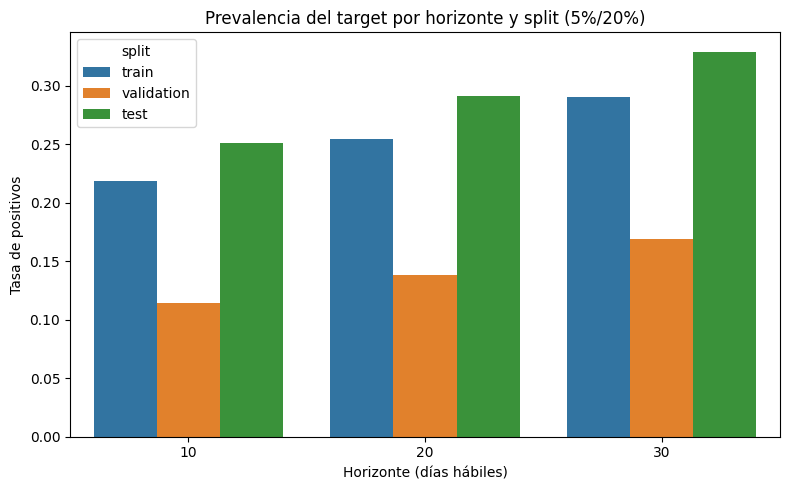

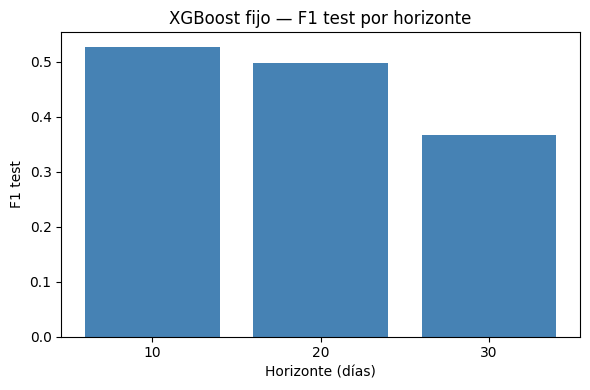

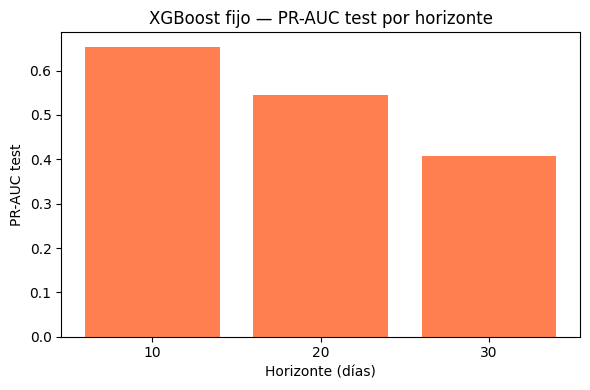

In [6]:
def build_horizon_dataset(df_source, horizon, dd_thr=BASE_DD, vol_thr=BASE_VOL):
    df = df_source.sort_values("date").reset_index(drop=True).copy()
    close = df["sp500_close"].to_numpy()
    fdd, fvol = compute_future_drawdown_and_vol(close, horizon)
    df[f"future_drawdown_{horizon}d"] = fdd
    df[f"future_vol_{horizon}d_ann"] = fvol
    df = df.iloc[:-horizon].copy() if horizon > 0 else df
    target_col = f"target_risk_{horizon}d"
    df[target_col] = make_combined_target(
        df[f"future_drawdown_{horizon}d"].values,
        df[f"future_vol_{horizon}d_ann"].values,
        dd_thr, vol_thr,
    )
    df = df.dropna(subset=FEATURE_COLS + [target_col]).reset_index(drop=True)
    return df, target_col


horizon_dist_rows = []
horizon_vix_rows = []
horizon_xgb_rows = []

for h in HORIZONS:
    df_h, tcol = build_horizon_dataset(df_target_full, h)
    train_m, val_m, test_m = assign_splits(df_h["date"])
    y_all = df_h[tcol].values
    rates = positive_rates(pd.Series(y_all), df_h["date"])
    horizon_dist_rows.append({
        "horizon_days": h,
        "positive_rate_full": rates["full"],
        "positive_rate_train": rates["train"],
        "positive_rate_validation": rates["validation"],
        "positive_rate_test": rates["test"],
        "n_full": len(df_h),
        "n_train": int(train_m.sum()),
        "n_validation": int(val_m.sum()),
        "n_test": int(test_m.sum()),
        "test_end_date": df_h.loc[test_m, "date"].max().strftime("%Y-%m-%d") if test_m.sum() else None,
    })

    for split_name, mask in [("validation", val_m), ("test", test_m)]:
        y_s = pd.Series(y_all)[mask].values
        vix_s = df_h.loc[mask, "vix"].values
        if len(np.unique(y_s)) < 2:
            roc, pr = np.nan, np.nan
        else:
            roc = roc_auc_score(y_s, vix_s)
            pr = average_precision_score(y_s, vix_s)
        horizon_vix_rows.append({
            "horizon_days": h, "split": split_name,
            "roc_auc": roc, "pr_auc": pr,
        })

    if XGBOOST_AVAILABLE:
        X_tr = df_h.loc[train_m, FEATURE_COLS]
        X_va = df_h.loc[val_m, FEATURE_COLS]
        X_te = df_h.loc[test_m, FEATURE_COLS]
        y_tr = pd.Series(y_all)[train_m].values
        y_va = pd.Series(y_all)[val_m].values
        y_te = pd.Series(y_all)[test_m].values
        thr, m_val, m_test = eval_xgb_fixed(X_tr, y_tr, X_va, y_va, X_te, y_te)
        horizon_xgb_rows.append({
            "horizon_days": h,
            "positive_rate_train": rates["train"],
            "positive_rate_validation": rates["validation"],
            "positive_rate_test": rates["test"],
            "best_threshold_validation": thr,
            "val_f1": m_val["f1"], "val_pr_auc": m_val["pr_auc"],
            "test_f1": m_test["f1"], "test_precision": m_test["precision"],
            "test_recall": m_test["recall"], "test_roc_auc": m_test["roc_auc"],
            "test_pr_auc": m_test["pr_auc"],
            "test_tn": m_test["tn"], "test_fp": m_test["fp"],
            "test_fn": m_test["fn"], "test_tp": m_test["tp"],
        })

horizon_sensitivity_distribution = pd.DataFrame(horizon_dist_rows)
horizon_sensitivity_vix = pd.DataFrame(horizon_vix_rows)
horizon_sensitivity_distribution.to_csv(
    REPORTS_TABLES / "horizon_sensitivity_distribution.csv", index=False
)
horizon_sensitivity_vix.to_csv(
    REPORTS_TABLES / "horizon_sensitivity_vix_auc.csv", index=False
)
display(horizon_sensitivity_distribution.round(4))
display(horizon_sensitivity_vix.round(4))

if horizon_xgb_rows:
    horizon_sensitivity_xgb = pd.DataFrame(horizon_xgb_rows)
    horizon_sensitivity_xgb.to_csv(
        REPORTS_TABLES / "horizon_sensitivity_xgb_results.csv", index=False
    )
    display(horizon_sensitivity_xgb.round(4))

    # Figuras horizonte
    dist_long = horizon_sensitivity_distribution.melt(
        id_vars=["horizon_days"],
        value_vars=["positive_rate_train", "positive_rate_validation", "positive_rate_test"],
        var_name="split", value_name="positive_rate",
    )
    dist_long["split"] = dist_long["split"].str.replace("positive_rate_", "")

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=dist_long, x="horizon_days", y="positive_rate", hue="split", ax=ax)
    ax.set_ylabel("Tasa de positivos")
    ax.set_xlabel("Horizonte (días hábiles)")
    ax.set_title("Prevalencia del target por horizonte y split (5%/20%)")
    fig.tight_layout()
    fig.savefig(REPORTS_FIGURES / "horizon_positive_rate_by_split.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(horizon_sensitivity_xgb["horizon_days"].astype(str), horizon_sensitivity_xgb["test_f1"], color="steelblue")
    ax.set_xlabel("Horizonte (días)")
    ax.set_ylabel("F1 test")
    ax.set_title("XGBoost fijo — F1 test por horizonte")
    fig.tight_layout()
    fig.savefig(REPORTS_FIGURES / "horizon_xgb_f1_test.png", dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(horizon_sensitivity_xgb["horizon_days"].astype(str), horizon_sensitivity_xgb["test_pr_auc"], color="coral")
    ax.set_xlabel("Horizonte (días)")
    ax.set_ylabel("PR-AUC test")
    ax.set_title("XGBoost fijo — PR-AUC test por horizonte")
    fig.tight_layout()
    fig.savefig(REPORTS_FIGURES / "horizon_xgb_prauc_test.png", dpi=150)
    plt.show()


### Interpretación — horizonte temporal

- Horizontes **más cortos** (10d) suelen tener **menor prevalencia** de eventos extremos; **30d** la aumenta.
- El **VIX** mantiene capacidad discriminativa en los tres horizontes, con variación en PR-AUC según split.
- **20 días** ofrece un compromiso entre señal financiera (ventana de gestión de riesgo) y estabilidad de prevalencia.
- Las fechas finales de test difieren ligeramente entre horizontes al eliminar las últimas *h* filas sin futuro.


## PARTE 6 — Conclusiones del Notebook 07

1. **Prevalencia razonable:** el target principal (20d, −5% drawdown, 20% vol) tiene ~25% positivos globalmente y tasas heterogéneas por split, acorde a cambios de régimen.
2. **Umbrales:** al variar drawdown (4–7%) y vol (18–25%), las tasas de positivos y métricas cambian de forma **gradual**, no caótica — las conclusiones cualitativas se mantienen.
3. **VIX fuerte:** como score continuo sigue siendo referencia sólida bajo definiciones alternativas (alto ROC/PR-AUC en test).
4. **XGBoost fijo:** mantiene capacidad discriminativa en escenarios alternativos; F1 test depende de la prevalencia del target.
5. **Horizonte 20d:** compromiso razonable frente a 10d (menos eventos) y 30d (más solapamiento, mayor prevalencia).
6. **Limitaciones:** sin gap de purga en sensibilidad de horizonte; sin re-tuning; test solo para evaluación; no sustituye la comparativa principal.
7. **Target principal sin cambios:** este notebook es **análisis complementario de sensibilidad**; `target_risk_20d` sigue siendo la definición oficial del TFM.
